In [1]:
import os
import pandas as pd
import numpy as np

METRO_DIR = "Metros"
YEARS = range(2010, 2025)

CBSA_CODES = ["12060", "16980", "19100", "26420", "33460", "38060"]
CBSA_NAME = {
    "12060": "Atlanta Metro",
    "16980": "Chicago Metro",
    "19100": "Dallas Metro",
    "26420": "Houston Metro",
    "33460": "Minneapolis Metro",
    "38060": "Phoenix Metro",
}

In [2]:
# Columns we will extract
POP_25_34 = "S0701_C01_005E"
POP_35_44 = "S0701_C01_006E"

PCT_25_34_SAME  = "S0701_C03_005E"
PCT_25_34_OTHER = "S0701_C04_005E"
PCT_25_34_ABRD  = "S0701_C05_005E"

PCT_35_44_SAME  = "S0701_C03_006E"
PCT_35_44_OTHER = "S0701_C04_006E"
PCT_35_44_ABRD  = "S0701_C05_006E"

required_cols = [
    "GEO_ID", "NAME",
    POP_25_34, POP_35_44,
    PCT_25_34_SAME, PCT_25_34_OTHER, PCT_25_34_ABRD,
    PCT_35_44_SAME, PCT_35_44_OTHER, PCT_35_44_ABRD
]

# Print the exact columns we will be using
print("\n🔎 Columns that will be extracted from each file:")
for c in required_cols:
    print(" •", c)


🔎 Columns that will be extracted from each file:
 • GEO_ID
 • NAME
 • S0701_C01_005E
 • S0701_C01_006E
 • S0701_C03_005E
 • S0701_C04_005E
 • S0701_C05_005E
 • S0701_C03_006E
 • S0701_C04_006E
 • S0701_C05_006E


In [3]:
rows = []

for year in YEARS:
    fname = f"{year}_Metros.csv"
    path = os.path.join(METRO_DIR, fname)
    if not os.path.exists(path):
        print(f"[WARN] Missing {path}, skipping...")
        continue

    df = pd.read_csv(path, dtype=str)
    df.columns = df.columns.str.strip()

    # Verify the file contains required columns
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{fname} missing required columns: {missing}")

    df["cbsa"] = df["GEO_ID"].astype(str).str.extract(r"(\d{5})$")
    df_sub = df[df["cbsa"].isin(CBSA_CODES)].copy()

    # Convert relevant columns to numeric
    for c in required_cols[2:]:
        df_sub[c] = pd.to_numeric(df_sub[c], errors="coerce")

    for _, r in df_sub.iterrows():
        cbsa = r["cbsa"]
        metro = CBSA_NAME.get(cbsa, r["NAME"])

        # Populations
        pop_25 = r[POP_25_34]
        pop_35 = r[POP_35_44]

        # Percentages (all domestic + abroad)
        pct_25 = r[PCT_25_34_SAME] + r[PCT_25_34_OTHER] + r[PCT_25_34_ABRD]
        pct_35 = r[PCT_35_44_SAME] + r[PCT_35_44_OTHER] + r[PCT_35_44_ABRD]

        movers_25 = pop_25 * (pct_25 / 100)
        movers_35 = pop_35 * (pct_35 / 100)

        prime = movers_25 + movers_35

        rows.append({
            "year": year,
            "cbsa": cbsa,
            "metro": metro,
            "prime_movers": prime,
            "movers_25_34": movers_25,
            "movers_35_44": movers_35,
            "pct_25_sum": pct_25,
            "pct_35_sum": pct_35,
        })

In [5]:
df_pm = pd.DataFrame(rows).sort_values(["metro", "year"]).reset_index(drop=True)

print("\nSample of final extracted dataset:")
print(df_pm.head())


Sample of final extracted dataset:
   year   cbsa          metro  prime_movers  movers_25_34  movers_35_44  \
0  2010  12060  Atlanta Metro    189178.585    117991.425     71187.160   
1  2011  12060  Atlanta Metro    183284.444    114636.750     68647.694   
2  2012  12060  Atlanta Metro    175497.070    108747.150     66749.920   
3  2013  12060  Atlanta Metro    172037.254    106417.010     65620.244   
4  2014  12060  Atlanta Metro    172226.602    107645.020     64581.582   

   pct_25_sum  pct_35_sum  
0        15.5         8.5  
1        15.0         8.2  
2        14.2         8.0  
3        13.9         7.9  
4        14.0         7.8  


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

# Make sure prime_movers is numeric
df_pm["prime_movers"] = pd.to_numeric(df_pm["prime_movers"], errors="coerce")

def mape(actual, pred):
    """Mean Absolute Percentage Error."""
    a = np.array(actual, dtype=float)
    p = np.array(pred, dtype=float)
    mask = (~np.isnan(a)) & (~np.isnan(p)) & (a != 0)
    if mask.sum() == 0:
        return np.inf
    return np.mean(np.abs(a[mask] - p[mask]) / np.abs(a[mask])) * 100.0

In [7]:
FUTURE_YEARS = [2025, 2026, 2027]
VAL_SIZE = 3  # last 3 years as validation

all_rows = []
model_summaries = []

for metro in sorted(df_pm["metro"].unique()):
    sub = df_pm[df_pm["metro"] == metro].sort_values("year").copy()
    if len(sub) < (VAL_SIZE + 4):  # need at least 4 train points + validation
        print(f"[WARN] {metro}: too few data points ({len(sub)}), skipping.")
        continue

    years = sub["year"].values
    y = sub["prime_movers"].values
    cbsa = sub["cbsa"].iloc[0]

    # ---- train / validation split ----
    train_years = years[:-VAL_SIZE]
    val_years   = years[-VAL_SIZE:]
    y_train     = y[:-VAL_SIZE]
    y_val       = y[-VAL_SIZE:]

    # ---------------- HOLT-DAMPED WITH TUNING ----------------
    # build time index for train only
    idx_train = pd.to_datetime(train_years.astype(str) + "-12-31")
    s_train = pd.Series(y_train, index=idx_train)

    holt_candidates = []
    # small grid for smoothing level, trend, and damping trend
    alpha_grid = [0.2, 0.4, 0.6, 0.8]
    beta_grid  = [0.1, 0.3, 0.5]
    phi_grid   = [0.8, 0.9, 0.98]

    best_holt = None
    best_holt_mape = np.inf

    for alpha in alpha_grid:
        for beta in beta_grid:
            for phi in phi_grid:
                try:
                    holt_model = ExponentialSmoothing(
                        s_train,
                        trend="add",
                        damped_trend=True,
                        seasonal=None,
                        initialization_method="estimated",
                    ).fit(
                        smoothing_level=alpha,
                        smoothing_trend=beta,
                        damping_trend=phi,
                        optimized=False
                    )
                    # forecast validation horizon
                    fc_val = holt_model.forecast(VAL_SIZE)
                    # align index with val_years
                    # fc_val index will be beyond last train date
                    holt_val_pred = fc_val.values

                    m = mape(y_val, holt_val_pred)
                    if m < best_holt_mape:
                        best_holt_mape = m
                        best_holt = (alpha, beta, phi)
                except Exception as e:
                    # some parameter combos might fail
                    continue

    # if tuning totally fails, fall back to auto-optimized Holt
    if best_holt is None:
        holt_model = ExponentialSmoothing(
            s_train,
            trend="add",
            damped_trend=True,
            seasonal=None,
            initialization_method="estimated",
        ).fit(optimized=True)
        fc_val = holt_model.forecast(VAL_SIZE)
        holt_val_pred = fc_val.values
        best_holt_mape = mape(y_val, holt_val_pred)
        best_holt = ("auto", "auto", "auto")
    else:
        alpha, beta, phi = best_holt
        holt_model = ExponentialSmoothing(
            s_train,
            trend="add",
            damped_trend=True,
            seasonal=None,
            initialization_method="estimated",
        ).fit(
            smoothing_level=alpha,
            smoothing_trend=beta,
            damping_trend=phi,
            optimized=False
        )
        fc_val = holt_model.forecast(VAL_SIZE)
        holt_val_pred = fc_val.values

    # ---------------- ARIMA (train-only) ----------------
    try:
        arima_model = pm.auto_arima(
            y_train,
            start_p=1, start_q=1,
            max_p=5, max_q=5,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False,
        )
        arima_val_pred = arima_model.predict(n_periods=VAL_SIZE)
        mape_arima = mape(y_val, arima_val_pred)
    except Exception as e:
        arima_model = None
        arima_val_pred = np.full(VAL_SIZE, np.nan)
        mape_arima = np.inf

    # ---------------- Pick best model on validation ----------------
    if best_holt_mape <= mape_arima:
        chosen_model_name = "holt_damped"
        chosen_val_mape   = best_holt_mape
    else:
        chosen_model_name = "arima"
        chosen_val_mape   = mape_arima

    model_summaries.append({
        "metro": metro,
        "cbsa": cbsa,
        "val_mape_holt": best_holt_mape,
        "val_mape_arima": mape_arima,
        "best_model": chosen_model_name,
        "best_val_mape": chosen_val_mape,
    })

    # ---------------- Refit chosen model on FULL data, then forecast ----------------
    # (train + validation, i.e. all 2010–2024)
    full_idx = pd.to_datetime(years.astype(str) + "-12-31")
    s_full = pd.Series(y, index=full_idx)

    if chosen_model_name == "holt_damped":
        # use tuned alpha/beta/phi if available
        if best_holt[0] == "auto":
            final_model = ExponentialSmoothing(
                s_full,
                trend="add",
                damped_trend=True,
                seasonal=None,
                initialization_method="estimated",
            ).fit(optimized=True)
        else:
            alpha, beta, phi = best_holt
            final_model = ExponentialSmoothing(
                s_full,
                trend="add",
                damped_trend=True,
                seasonal=None,
                initialization_method="estimated",
            ).fit(
                smoothing_level=alpha,
                smoothing_trend=beta,
                damping_trend=phi,
                optimized=False
            )
        fitted_full = final_model.fittedvalues
        fc_future = final_model.forecast(len(FUTURE_YEARS))
        future_preds = fc_future.values

    else:  # ARIMA chosen
        final_model = pm.auto_arima(
            y,
            start_p=1, start_q=1,
            max_p=5, max_q=5,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False,
        )
        fitted_full = final_model.predict_in_sample()
        future_preds = final_model.predict(n_periods=len(FUTURE_YEARS))

    # ---------------- Store historical fitted ----------------
    for year, actual, pred in zip(years, y, fitted_full):
        err = np.nan
        if actual != 0 and not np.isnan(actual) and not np.isnan(pred):
            err = abs(actual - pred) / abs(actual) * 100.0

        all_rows.append({
            "metro": metro,
            "cbsa": cbsa,
            "year": int(year),
            "prime_movers_actual": float(actual),
            "prime_movers_pred": float(pred),
            "error_pct": err,
            "is_forecast": 0,
            "model_used": chosen_model_name,
        })

    # ---------------- Store future forecasts ----------------
    for year, pred in zip(FUTURE_YEARS, future_preds):
        all_rows.append({
            "metro": metro,
            "cbsa": cbsa,
            "year": int(year),
            "prime_movers_actual": np.nan,
            "prime_movers_pred": float(pred),
            "error_pct": np.nan,
            "is_forecast": 1,
            "model_used": chosen_model_name,
        })

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YE-DEC will be used.
  self._init_dates(dates, freq)
/Library/Fra

In [8]:
df_models = pd.DataFrame(model_summaries)
print("📊 Validation summary per metro:")
print(df_models)

df_forecast = (
    pd.DataFrame(all_rows)
    .sort_values(["metro", "year"])
    .reset_index(drop=True)
)

print("\n🔍 Forecast sample:")
print(df_forecast.head())

out_file = "prime_movers_forecast_hybrid_validated_2010_2027.xlsx"
df_forecast.to_excel(out_file, index=False)
print(f"\n Saved to: {out_file}")

📊 Validation summary per metro:
               metro   cbsa  val_mape_holt  val_mape_arima   best_model  \
0      Atlanta Metro  12060       1.880333       72.683742  holt_damped   
1      Chicago Metro  16980       2.365759        3.070926  holt_damped   
2       Dallas Metro  19100       5.150489       12.526573  holt_damped   
3      Houston Metro  26420       2.814938       15.664402  holt_damped   
4  Minneapolis Metro  33460       6.279623       73.580537  holt_damped   
5      Phoenix Metro  38060       3.451700        5.991143  holt_damped   

   best_val_mape  
0       1.880333  
1       2.365759  
2       5.150489  
3       2.814938  
4       6.279623  
5       3.451700  

🔍 Forecast sample:
           metro   cbsa  year  prime_movers_actual  prime_movers_pred  \
0  Atlanta Metro  12060  2010           189178.585      179750.480467   
1  Atlanta Metro  12060  2011           183284.444      185155.288109   
2  Atlanta Metro  12060  2012           175497.070      185641.159532 

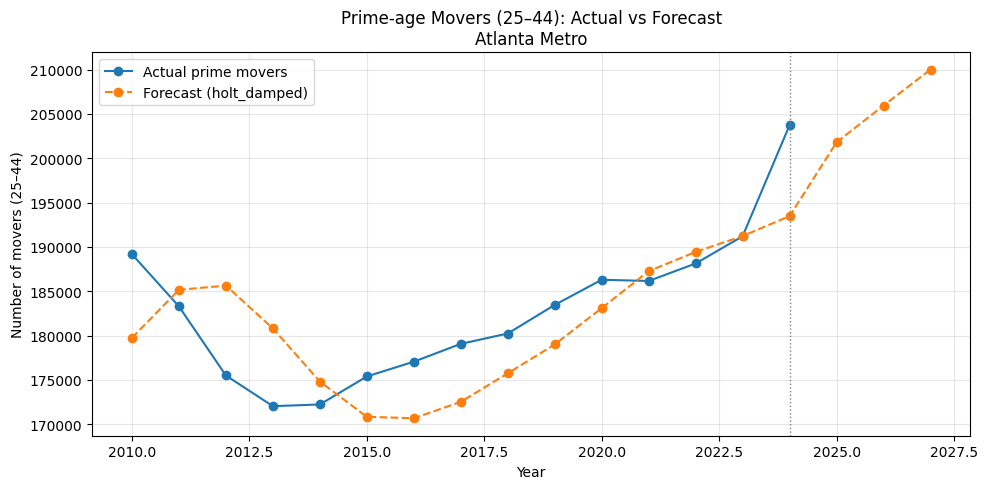

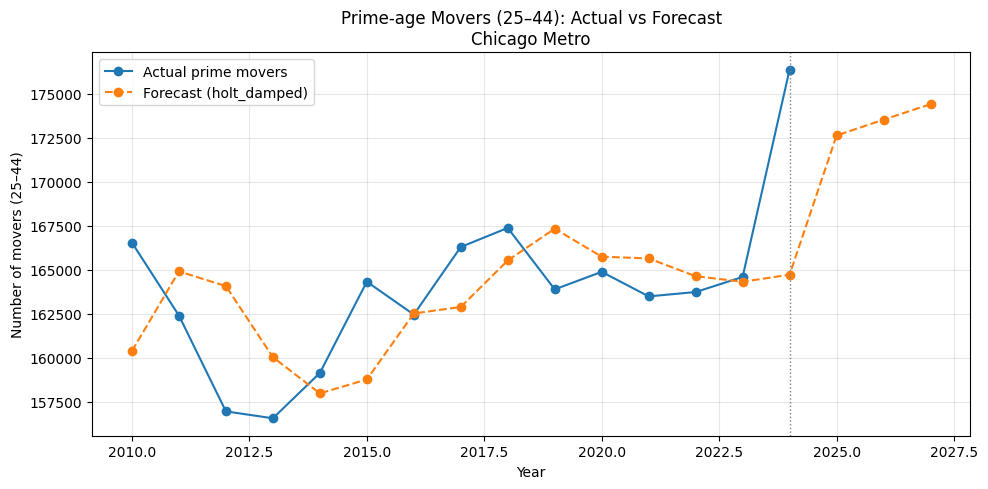

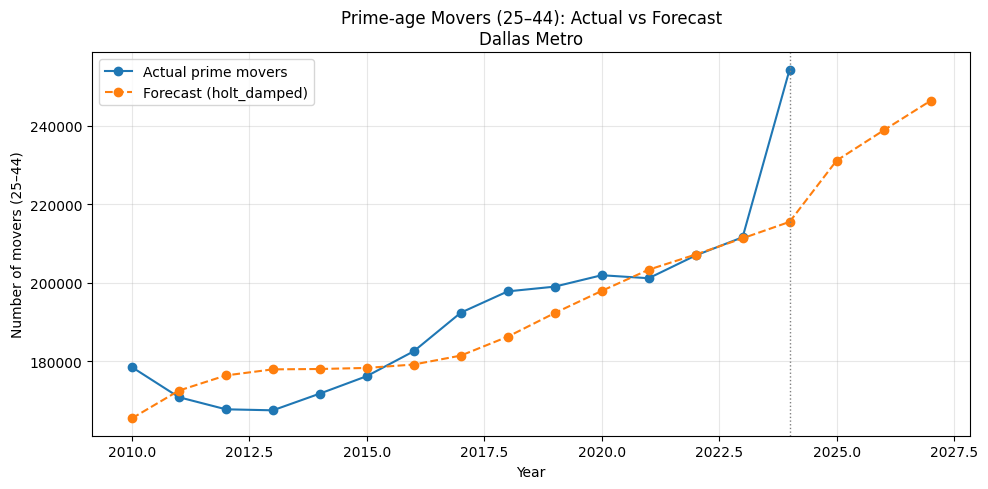

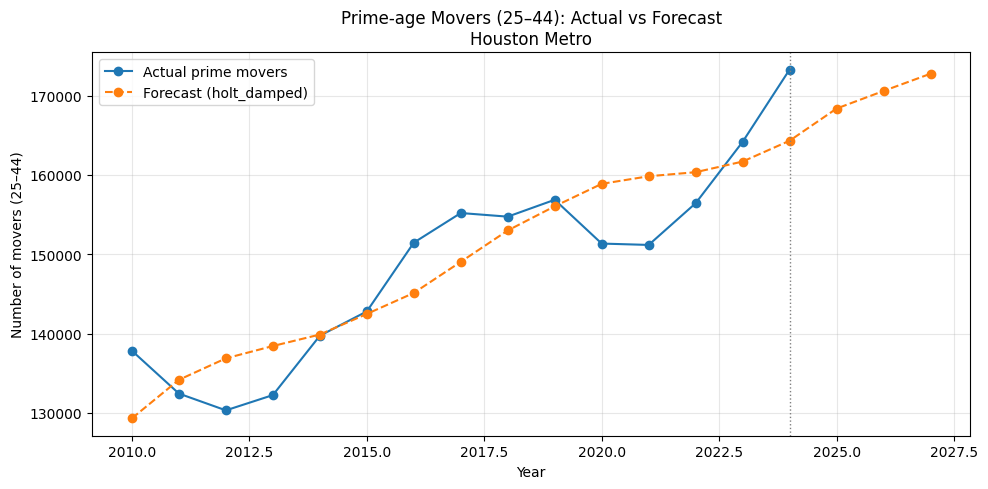

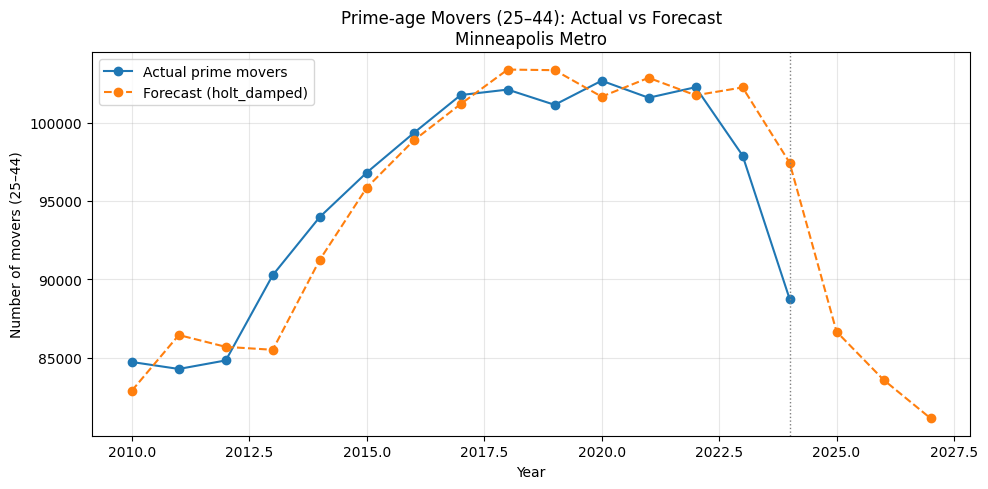

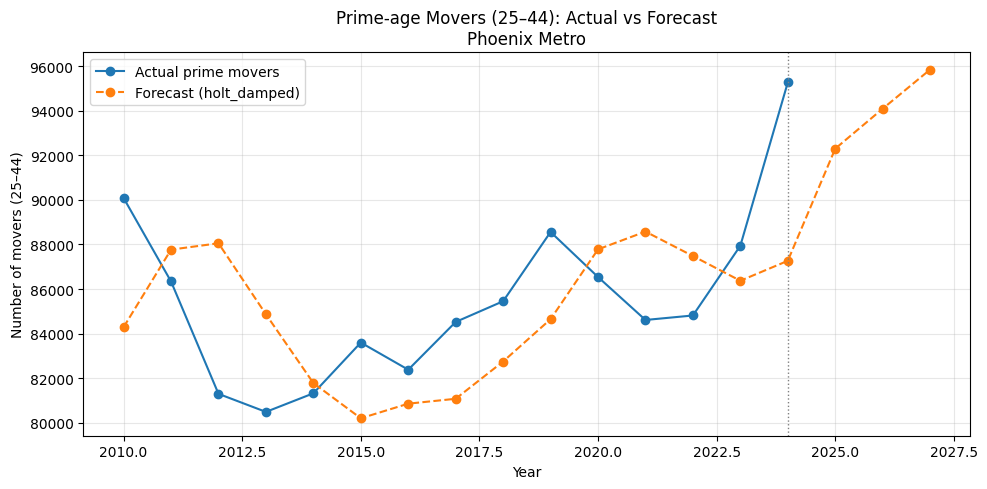

In [9]:
for metro in sorted(df_forecast["metro"].unique()):
    sub = df_forecast[df_forecast["metro"] == metro].copy()
    sub = sub[sub["year"] >= 2010]

    hist = sub[sub["is_forecast"] == 0]
    full = sub

    plt.figure(figsize=(10, 5))

    plt.plot(
        hist["year"],
        hist["prime_movers_actual"],
        marker="o",
        linestyle="-",
        label="Actual prime movers"
    )

    plt.plot(
        full["year"],
        full["prime_movers_pred"],
        marker="o",
        linestyle="--",
        label=f"Forecast ({full['model_used'].iloc[0]})"
    )

    last_hist_year = hist["year"].max()
    plt.axvline(x=last_hist_year, color="gray", linestyle=":", linewidth=1)

    plt.title(f"Prime-age Movers (25–44): Actual vs Forecast\n{metro}")
    plt.xlabel("Year")
    plt.ylabel("Number of movers (25–44)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()